#QUANTUM PORTFOLIO OPTIMIZATION

---

##0.REFERENCE

##1.CONTEXT


*Introduction*

Portfolio optimization is one of the most important applications of quantitative finance. At its core, the problem asks how an investor should distribute capital across a collection of assets in order to balance expected return, risk, diversification, and practical investment constraints. In a traditional setting, the decision variables are portfolio weights, and the investor seeks an allocation that maximizes expected return for a chosen level of risk or minimizes risk for a desired level of return. The classical mathematical structure was formalized through mean-variance optimization, where expected returns are represented by a vector and risk is represented by a covariance matrix.

This notebook studies a simplified but conceptually important version of the portfolio optimization problem. Instead of assigning a continuous weight to every asset, the model treats each asset as a binary decision. An asset is either selected or not selected. With fifteen available assets, the decision is represented by fifteen binary variables. A value of one means that the corresponding asset is included in the portfolio, while a value of zero means that it is excluded. The notebook imposes a cardinality constraint requiring exactly five assets to be selected. Once the five assets are chosen, the portfolio is interpreted as equally weighted across those selected positions.

The binary formulation is particularly useful for understanding how a classical optimization problem can be encoded in a quantum framework. Each binary asset-selection variable can be associated with one qubit. A fifteen-asset portfolio therefore corresponds to a fifteen-qubit computational basis state. For example, a state whose first, third, fifth, seventh, and ninth entries are one represents a portfolio containing those five assets. The complete state space contains \(2^{15}=32{,}768\) possible binary portfolios. Only a subset of those portfolios satisfies the requirement that exactly five assets be selected.

The notebook constructs a classical portfolio cost function with three components. The first component represents portfolio risk and is calculated using the covariance matrix. The second component rewards expected return by subtracting the return score from the cost. The third component penalizes violations of the cardinality constraint. The resulting function is a quadratic unconstrained binary optimization problem, commonly called a QUBO. The QUBO structure is especially useful because it can be translated into a cost Hamiltonian that is diagonal in the computational basis.

The central quantum algorithm used in the notebook is the Quantum Approximate Optimization Algorithm, or QAOA. QAOA is a hybrid quantum-classical method designed for combinatorial optimization. It begins with an equal superposition of all possible binary portfolios. A cost unitary then applies a phase to each portfolio according to its objective-function value. Better and worse portfolios receive different phases. A mixer unitary subsequently allows amplitudes associated with different portfolios to interact. Through interference, the probability distribution over candidate portfolios can be reshaped.

The QAOA circuit is controlled by parameters conventionally called gamma and beta. Gamma determines the strength of the cost-dependent phase transformation, while beta determines the strength of the mixing transformation. These parameters are not known in advance. A classical optimization routine therefore evaluates the expected cost generated by the quantum state and searches for parameter values that reduce it. This interaction between a quantum state preparation process and a classical optimizer is one of the defining characteristics of variational quantum algorithms.

The notebook uses a statevector simulation rather than an actual quantum processor. The full complex amplitude vector of all \(32{,}768\) portfolio states is represented directly in memory using NumPy. This approach is practical for fifteen qubits and has important pedagogical advantages. It makes the quantum transformations explicit, allows probabilities to be calculated exactly, and provides a transparent environment in which the relationship between the cost Hamiltonian, the phase transformation, the mixer, and the final probability distribution can be examined.

The purpose of the notebook is not to claim quantum advantage. A fifteen-asset problem is small enough to solve classically by exhaustive enumeration, and the notebook intentionally calculates the exact classical optimum as a benchmark. This allows the QAOA result to be evaluated objectively. The difference between the QAOA-selected portfolio cost and the exact optimum is reported as an optimality gap. The exact benchmark is therefore not a competitor to the demonstration but an essential control that makes the exercise measurable and auditable.

The financial data used in the notebook are synthetic and reproducible. Expected returns are generated from a fixed random seed. The covariance matrix is constructed from a factor model and rescaled to produce realistic annualized volatilities. This design ensures that every user running the notebook with the same configuration receives the same input data and can independently reproduce the results. It also avoids dependence on external market-data services, changing prices, network availability, or licensing restrictions.

Governance and auditability are treated as core design requirements rather than optional additions. The notebook records the model configuration, random seed, software environment, optimizer evaluations, selected parameters, sampled states, financial results, and exact benchmark. It creates machine-readable JSON and JSONL files, stores the encoded problem, saves a probability chart, and generates SHA-256 hashes for the resulting evidence. These files are consolidated into an audit package that can be reviewed independently.

The final cell introduces a controlled large language model component using `claude-haiku-4-5-20251001`. The API key is retrieved from the Google Colab Secrets environment under the name `ANTHROPIC_API_KEY`. The language model does not determine the portfolio, modify the optimization process, or generate the financial inputs. Its role is strictly explanatory. It receives structured results from the completed analysis and produces a narrative describing the notebook architecture, the QAOA mechanism, the selected portfolio, the classical benchmark, the limitations, and the governance controls.

To preserve auditability, the exact prompt sent to the language model is recorded along with the model identifier, temperature, token usage, response, and prompt hash. The temperature is set to zero to reduce unnecessary variation. The LLM output is therefore treated as a reporting layer rather than as an optimization engine. The numerical results remain fully determined by the explicit mathematical model and the recorded computation.

This notebook should be understood as a bridge between classical portfolio theory and quantum optimization. It demonstrates how financial decisions can be represented as bit strings, how a risk-return objective can become a Hamiltonian, how quantum evolution can encode costs as phases, and how interference can influence the probability of observing different portfolios. At the same time, it shows how exact benchmarking, deterministic inputs, comprehensive logs, and controlled LLM reporting can make an experimental quantum model more governable, explainable, and suitable for serious review.




##2.CODE AND IMPLEMENTATION


*Cell 1 — Installation, imports, and runtime verification*

The first cell prepares the Google Colab environment and verifies the principal software components required by the notebook. It installs the Anthropic Python package, which will be used only in the final explanatory cell. The cell then imports NumPy for numerical computation, SciPy for classical parameter optimization, Matplotlib for visualization, and standard Python libraries for logging, hashing, archiving, timestamps, and file management. The `google.colab.userdata` interface is imported so that the Anthropic API key can later be retrieved securely from the Colab Secrets panel. A timezone-aware UTC timestamp function is defined to ensure consistent audit records. Finally, the cell prints the Python, NumPy, SciPy, and Anthropic versions together with the current UTC time. These environment details are important because package versions can affect numerical behavior, optimizer performance, and API compatibility. The cell therefore establishes both the computational foundation and the first layer of reproducibility.



*Cell 2 — Governance configuration and audit directories*

The second cell defines the complete model configuration in a single transparent dictionary. It specifies the number of assets, the number of assets to be selected, the QAOA depth, risk-aversion coefficient, return weight, cardinality penalty, number of measurement shots, random seed, optimizer method, iteration limit, and Anthropic model identifier. Centralizing these assumptions makes the model easier to inspect and govern. The fixed random seed ensures that the generated financial inputs and simulated measurements can be reproduced. The cell also creates a structured audit directory containing separate locations for logs, data, and results. Two helper functions are defined: one writes formatted JSON files, and the other appends individual events to a JSON Lines log. The configuration is saved immediately, and a run-initialization event is recorded with a UTC timestamp. This cell establishes the notebook’s control framework before any financial data or optimization results are produced.

*Cell 3 — Creation of the fifteen-asset financial dataset*

The third cell generates a reproducible synthetic dataset for fifteen assets. Each asset receives an annual expected return drawn from a specified range using the fixed random-number generator established earlier. The covariance matrix is produced through a three-factor structure. Each asset is assigned factor exposures, the factors are given their own variances, and an idiosyncratic variance is added to each asset. This construction guarantees a positive-semidefinite covariance matrix, which is necessary for a coherent representation of portfolio risk. The matrix is then rescaled so that individual annualized volatilities fall within a realistic range. The expected-return vector, covariance matrix, and asset names are stored in a NumPy archive for later inspection. The cell records the number of assets, the return range, and the minimum covariance eigenvalue in the run log. It finally prints a simple table showing each asset’s expected return and volatility, allowing the user to inspect the financial inputs before optimization begins.

*Cell 4 — Encoding the portfolio objective as a QUBO*

The fourth cell translates the financial decision problem into a binary optimization structure. Fifteen binary variables produce \(2^{15}=32{,}768\) possible portfolio states. The cell constructs all bit strings simultaneously, where each row represents one portfolio and each column corresponds to one asset. It calculates the number of selected assets, the total expected-return score, and the quadratic covariance-risk score for every candidate portfolio. The complete cost function combines three elements: a risk penalty, a negative return term, and a squared penalty for selecting a number of assets different from five. This creates a QUBO whose value can be associated with each computational-basis state. The cell identifies all portfolios satisfying the five-asset requirement and calculates the exact best valid portfolio by exhaustive classical enumeration. This exact solution is saved as a benchmark. The encoded state space, costs, cardinalities, and validity mask are stored for audit purposes, together with a log of the state-space size and exact optimum.

*Cell 5 — Definition of the QAOA statevector circuit*

The fifth cell defines the quantum transformations used in the simulation. The cost unitary multiplies every portfolio amplitude by a complex phase determined by its cost and the parameter gamma. Because the portfolio Hamiltonian is diagonal in the computational basis, this operation can be implemented efficiently by elementwise multiplication. The mixer unitary applies an \(X\)-rotation to each simulated qubit and allows amplitude to move between states whose bit strings differ. The QAOA state begins as a uniform superposition over all \(32{,}768\) portfolios. The cost transformation and mixer are then applied sequentially. A function calculates the expected portfolio cost by multiplying each state probability by its corresponding objective value. Every evaluation is appended to an optimizer-trace log with gamma, beta, expected cost, evaluation number, and UTC timestamp. The cell concludes by checking that the statevector norm remains one, confirming that the implemented transformations preserve total probability as required by unitary quantum evolution.

*Cell 6 — Classical optimization of gamma and beta*

The sixth cell searches for the QAOA parameters that minimize the expected value of the portfolio cost Hamiltonian. It first performs a deterministic coarse-grid search over candidate gamma and beta values. This provides a transparent and reproducible starting point rather than relying on an arbitrary random initialization. The best grid point is then passed to the SciPy L-BFGS-B optimizer, which refines the parameters within explicit bounds. Each objective-function evaluation is already recorded by the logging mechanism defined in the previous cell. Once the optimization terminates, the cell stores whether the solver reported success, its status code, message, total number of evaluations, optimized gamma and beta, and final expected cost. These details are saved in a structured JSON file. The optimization process is hybrid: the statevector routine represents the quantum component, while the SciPy routine performs the classical parameter search. The resulting parameters determine the final QAOA probability distribution over candidate portfolios.

*Cell 7 — Sampling the optimized quantum distribution*

The seventh cell evaluates the optimized QAOA state and converts its amplitudes into probabilities. It then simulates repeated quantum measurements by drawing a specified number of portfolio states according to that probability distribution. This process approximates what would occur if the circuit were executed repeatedly on quantum hardware. The resulting measurement counts are recorded for every observed state. The cell filters the observations to portfolios that satisfy the requirement of selecting exactly five assets. Among the valid portfolios actually sampled, it identifies the one with the lowest encoded cost. This choice avoids automatically assuming that the most frequently observed state must also be the best financially valid state. The complete observed-state table is saved as a CSV file containing state identifier, measurement count, cardinality, objective cost, and exact simulated probability. The cell prints the selected bit vector, corresponding asset names, portfolio cost, and measurement frequency. These outputs provide a direct bridge between the quantum probability distribution and the classical investment decision.

*Cell 8 — Financial metrics and exact classical comparison*

The eighth cell translates the selected binary portfolio into a financial allocation. Because the model selects assets rather than continuous weights, the chosen positions are assigned equal weights. The cell calculates annual expected return, portfolio variance, volatility, and a zero-risk-free-rate Sharpe ratio. The same calculations are performed for the exact classical optimum identified through exhaustive enumeration. The QAOA portfolio and exact benchmark are then assembled into a structured results object containing bit vectors, selected asset names, state identifiers, costs, sample counts, portfolio weights, financial metrics, and optimized parameters. The optimality gap is calculated as the difference between the QAOA-selected cost and the exact minimum cost. A gap of zero indicates that the QAOA sampling process found the exact optimum, while a positive value measures the degree of suboptimality. The complete result set is saved as JSON, and a summary event is added to the audit log. This cell provides the main quantitative basis for evaluating the model.

*Cell 9 — Visualization of the leading valid portfolios*

The ninth cell visualizes the most probable valid portfolios in the optimized QAOA state. It first isolates the states that select exactly five assets, then ranks them by their exact simulated probabilities. The twelve highest-probability portfolios are displayed in a bar chart. Each portfolio is labeled with its fifteen-bit decision vector, where a value of one means that the corresponding asset is selected. The chart is saved as a high-resolution image in the results directory before being displayed in the notebook. This visualization helps the user see whether probability is concentrated around a small number of promising portfolios or remains broadly distributed across many alternatives. It is important to distinguish probability from objective quality: a highly probable state is not automatically the lowest-cost state. For that reason, the earlier cells separately calculate costs and exact benchmarks. The chart is therefore a diagnostic representation of the QAOA distribution rather than a substitute for financial or optimization analysis.

*Cell 10 — Construction of the governance and audit package*

The tenth cell consolidates the notebook’s model-risk and audit evidence. It records the Python version, operating platform, and package versions in an environment file. A helper function calculates the SHA-256 cryptographic hash of every artifact. These hashes allow an independent reviewer to confirm whether any configuration, dataset, log, result, or chart has been changed after the model run. The cell creates a manifest listing each file, its size, and its hash. It then packages the configuration, environment record, input data, encoded problem, optimizer trace, result files, chart, and logs into a compressed ZIP archive. The archive itself is also assigned a SHA-256 digest, and its creation is written to the run log. This does not prove that the model is financially valid, but it creates evidence of what was executed and what outputs were produced. The audit package supports reproducibility, change detection, model review, and formal documentation of the experiment.

*Cell 11 — Governed LLM explanation using Claude Haiku*

The eleventh cell uses `claude-haiku-4-5-20251001` to generate a narrative explanation of the notebook and its results. The Anthropic API key is retrieved securely from the Colab Secrets section under `ANTHROPIC_API_KEY`; it is never printed or stored in the audit files. The prompt provides Claude with the configuration, optimizer summary, portfolio results, exact benchmark, and governance controls. The model is instructed to explain the architecture, quantum encoding, cost Hamiltonian, QAOA process, optimized parameters, selected portfolio, optimality gap, limitations, and validation requirements. It is explicitly prohibited from claiming quantum advantage and must distinguish statevector simulation from real quantum-hardware execution. Temperature is set to zero to reduce output variability. For auditability, the complete prompt, response, model name, token usage, timestamp, and prompt hash are stored. The final audit ZIP is rebuilt so that the LLM evidence is included. The LLM acts solely as an explanatory reporting layer and does not influence the optimization results.


In [1]:
# CELL 1 — INSTALL, IMPORTS, AND RUNTIME CHECK
%pip install -q anthropic

import os
import sys
import json
import math
import time
import hashlib
import zipfile
import platform
import datetime
import importlib.metadata

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.optimize import minimize
from google.colab import userdata

UTC_NOW = lambda: datetime.datetime.now(datetime.timezone.utc).isoformat()

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("SciPy:", importlib.metadata.version("scipy"))
print("Anthropic:", importlib.metadata.version("anthropic"))
print("UTC:", UTC_NOW())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 11.2 MB/s eta 0:00:00
Python: 3.12.13
NumPy: 2.0.2
SciPy: 1.16.3
Anthropic: 0.109.2
UTC: 2026-06-16T23:19:58.569153+00:00


In [2]:
# CELL 2 — GOVERNANCE CONFIGURATION, REPRODUCIBILITY, AND AUDIT DIRECTORIES
CONFIG = {
    "project_name": "15_asset_qaoa_portfolio",
    "n_assets": 15,
    "target_assets": 5,
    "qaoa_depth_p": 1,
    "risk_aversion": 0.70,
    "return_weight": 1.00,
    "cardinality_penalty": 4.00,
    "shots": 5000,
    "random_seed": 20260616,
    "optimizer_method": "L-BFGS-B",
    "optimizer_maxiter": 120,
    "model_name": "claude-haiku-4-5-20251001"
}

np.random.seed(CONFIG["random_seed"])
RNG = np.random.default_rng(CONFIG["random_seed"])

ROOT = Path("/content/portfolio_qaoa_audit")
LOG_DIR = ROOT / "logs"
DATA_DIR = ROOT / "data"
RESULT_DIR = ROOT / "results"

for folder in (ROOT, LOG_DIR, DATA_DIR, RESULT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def write_json(path, obj):
    Path(path).write_text(
        json.dumps(obj, indent=2, sort_keys=True),
        encoding="utf-8"
    )

def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, sort_keys=True) + "\n")

write_json(ROOT / "config.json", CONFIG)

append_jsonl(
    LOG_DIR / "run_log.jsonl",
    {
        "event": "run_initialized",
        "timestamp_utc": UTC_NOW(),
        "config": CONFIG
    }
)

print(json.dumps(CONFIG, indent=2))
print("Audit root:", ROOT)

{
  "project_name": "15_asset_qaoa_portfolio",
  "n_assets": 15,
  "target_assets": 5,
  "qaoa_depth_p": 1,
  "risk_aversion": 0.7,
  "return_weight": 1.0,
  "cardinality_penalty": 4.0,
  "shots": 5000,
  "random_seed": 20260616,
  "optimizer_method": "L-BFGS-B",
  "optimizer_maxiter": 120,
  "model_name": "claude-haiku-4-5-20251001"
}
Audit root: /content/portfolio_qaoa_audit


In [3]:
# CELL 3 — CREATE A REPRODUCIBLE 15-ASSET MARKET DATASET
ASSET_NAMES = np.array([
    "Asset_01", "Asset_02", "Asset_03", "Asset_04", "Asset_05",
    "Asset_06", "Asset_07", "Asset_08", "Asset_09", "Asset_10",
    "Asset_11", "Asset_12", "Asset_13", "Asset_14", "Asset_15"
])

n = CONFIG["n_assets"]

# Reproducible synthetic annual expected returns.
mu = RNG.uniform(0.06, 0.18, size=n)

# Positive-semidefinite covariance matrix from a three-factor model.
factor_loadings = RNG.normal(0.0, 0.12, size=(n, 3))
factor_cov = np.diag([0.035, 0.020, 0.012])
idiosyncratic_var = RNG.uniform(0.010, 0.030, size=n)

sigma = (
    factor_loadings
    @ factor_cov
    @ factor_loadings.T
    + np.diag(idiosyncratic_var)
)

# Rescale the covariance matrix to realistic annual volatilities.
target_vols = RNG.uniform(0.14, 0.30, size=n)
current_vols = np.sqrt(np.diag(sigma))
scale = target_vols / current_vols

sigma = np.diag(scale) @ sigma @ np.diag(scale)

np.savez(
    DATA_DIR / "market_inputs.npz",
    asset_names=ASSET_NAMES,
    expected_returns=mu,
    covariance=sigma
)

append_jsonl(
    LOG_DIR / "run_log.jsonl",
    {
        "event": "market_data_created",
        "timestamp_utc": UTC_NOW(),
        "n_assets": int(n),
        "return_min": float(mu.min()),
        "return_max": float(mu.max()),
        "covariance_min_eigenvalue": float(
            np.linalg.eigvalsh(sigma).min()
        )
    }
)

print("Asset   Expected Return   Volatility")

for i in range(n):
    print(
        f"{ASSET_NAMES[i]:8s} "
        f"{mu[i]:16.4%} "
        f"{np.sqrt(sigma[i, i]):12.4%}"
    )

Asset   Expected Return   Volatility
Asset_01          6.3287%     24.7687%
Asset_02         15.3120%     28.6732%
Asset_03         15.6498%     16.5520%
Asset_04          6.2194%     29.3582%
Asset_05         16.3723%     26.8277%
Asset_06          9.0602%     20.9180%
Asset_07         11.0578%     15.3733%
Asset_08          9.3528%     27.4654%
Asset_09         17.2912%     27.3161%
Asset_10         16.4775%     26.2862%
Asset_11          8.3091%     14.1419%
Asset_12          9.1684%     28.3827%
Asset_13          8.7590%     21.3680%
Asset_14          6.1366%     23.7166%
Asset_15         11.8046%     18.9268%


In [4]:
# CELL 4 — ENCODE THE PORTFOLIO OBJECTIVE AS A QUBO/COST HAMILTONIAN

# Every computational-basis state represents one binary portfolio.
#
# Example:
# [1, 0, 1, 0, ...]
#
# means that Assets 1 and 3 are selected.

N_STATES = 2 ** n

state_ids = np.arange(
    N_STATES,
    dtype=np.uint32
)

X = (
    (
        state_ids[:, None]
        >> np.arange(n, dtype=np.uint32)
    )
    & 1
).astype(np.float64)

cardinality = X.sum(axis=1)

portfolio_return_score = X @ mu

portfolio_risk_score = np.einsum(
    "bi,ij,bj->b",
    X,
    sigma,
    X,
    optimize=True
)

# Classical portfolio cost:
#
# cost =
# risk penalty
# - expected-return reward
# + penalty for violating the five-asset requirement

costs = (
    CONFIG["risk_aversion"]
    * portfolio_risk_score

    - CONFIG["return_weight"]
    * portfolio_return_score

    + CONFIG["cardinality_penalty"]
    * (
        cardinality
        - CONFIG["target_assets"]
    ) ** 2
)

valid_mask = (
    cardinality
    == CONFIG["target_assets"]
)

valid_state_ids = state_ids[valid_mask]
valid_costs = costs[valid_mask]

exact_best_state_id = int(
    valid_state_ids[
        np.argmin(valid_costs)
    ]
)

exact_best_bits = (
    X[exact_best_state_id]
    .astype(int)
)

np.savez(
    DATA_DIR / "encoded_problem.npz",
    state_ids=state_ids,
    binary_portfolios=X.astype(np.uint8),
    costs=costs,
    cardinality=cardinality,
    valid_mask=valid_mask
)

append_jsonl(
    LOG_DIR / "run_log.jsonl",
    {
        "event": "qubo_encoded",
        "timestamp_utc": UTC_NOW(),
        "state_space_size": int(N_STATES),
        "valid_portfolios": int(valid_mask.sum()),
        "exact_best_state_id": exact_best_state_id,
        "exact_best_cost": float(
            costs[exact_best_state_id]
        )
    }
)

print("Total candidate portfolios:", N_STATES)

print(
    "Valid portfolios with exactly",
    CONFIG["target_assets"],
    "assets:",
    int(valid_mask.sum())
)

print(
    "Exact classical optimum bit vector:",
    exact_best_bits.tolist()
)

print(
    "Exact classical optimum cost:",
    float(costs[exact_best_state_id])
)

Total candidate portfolios: 32768
Valid portfolios with exactly 5 assets: 3003
Exact classical optimum bit vector: [0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1]
Exact classical optimum cost: -0.5637158849262117


In [7]:
# CELL 5 — DEFINE THE STATEVECTOR QAOA CIRCUIT

def apply_cost_unitary(
    state,
    gamma,
    diagonal_costs
):
    """
    Apply:

        U_C(gamma) = exp(-i gamma H_C)

    Because H_C is diagonal in the portfolio basis,
    every portfolio amplitude receives a cost-dependent phase.
    """

    return (
        state
        * np.exp(
            -1j
            * gamma
            * diagonal_costs
        )
    )


def apply_mixer_unitary(
    state,
    beta,
    n_qubits
):
    """
    Apply:

        U_M(beta) = exp(-i beta sum_i X_i)

    The mixer allows probability amplitude to move between
    portfolios whose bit strings differ.
    """

    out = state.copy()

    c = np.cos(beta)
    s = -1j * np.sin(beta)

    for q in range(n_qubits):

        step = 1 << q
        block = step << 1

        reshaped = out.reshape(
            -1,
            block
        )

        left = reshaped[:, :step].copy()
        right = reshaped[:, step:].copy()

        reshaped[:, :step] = (
            c * left
            + s * right
        )

        reshaped[:, step:] = (
            s * left
            + c * right
        )

        out = reshaped.reshape(-1)

    return out


def qaoa_state(params):
    """
    Construct a depth-p=1 QAOA state.

    params[0] = gamma
    params[1] = beta
    """

    gamma, beta = params

    # Uniform superposition of all 2^15 portfolios.
    state = (
        np.ones(
            N_STATES,
            dtype=np.complex128
        )
        / np.sqrt(N_STATES)
    )

    state = apply_cost_unitary(
        state,
        gamma,
        costs
    )

    state = apply_mixer_unitary(
        state,
        beta,
        n
    )

    return state


EVAL_COUNTER = {
    "count": 0
}


def expected_cost(params):
    """
    Objective supplied to the classical optimizer.
    """

    state = qaoa_state(params)

    probabilities = (
        np.abs(state) ** 2
    )

    value = float(
        probabilities @ costs
    )

    EVAL_COUNTER["count"] += 1

    append_jsonl(
        LOG_DIR / "optimizer_trace.jsonl",
        {
            "evaluation": EVAL_COUNTER["count"],
            "timestamp_utc": UTC_NOW(),
            "gamma": float(params[0]),
            "beta": float(params[1]),
            "expected_cost": value
        }
    )

    return value


test_state = qaoa_state(
    np.array([0.10, 0.20])
)

print(
    "Statevector norm:",
    float(
        np.vdot(
            test_state,
            test_state
        ).real
    )
)

print(
    "Test expected cost:",
    expected_cost(
        np.array([0.10, 0.20])
    )
)

Statevector norm: 0.9999999999999999
Test expected cost: 64.0261415915896


In [8]:
# CELL 6 — OPTIMIZE THE QAOA PARAMETERS WITH FULL TRACE LOGGING

# A deterministic coarse search supplies an auditable
# starting point for the numerical optimizer.

gamma_grid = np.linspace(
    0.0,
    2.0 * np.pi,
    13
)

beta_grid = np.linspace(
    0.0,
    np.pi,
    13
)

best_grid_value = np.inf
best_grid_params = None

for gamma in gamma_grid:
    for beta in beta_grid:

        candidate_params = np.array([
            gamma,
            beta
        ])

        value = expected_cost(
            candidate_params
        )

        if value < best_grid_value:

            best_grid_value = value
            best_grid_params = (
                candidate_params.copy()
            )

print(
    "Best coarse-grid parameters:",
    best_grid_params
)

print(
    "Best coarse-grid objective:",
    best_grid_value
)

result = minimize(
    expected_cost,
    x0=best_grid_params,
    method=CONFIG["optimizer_method"],
    bounds=[
        (0.0, 2.0 * np.pi),
        (0.0, np.pi)
    ],
    options={
        "maxiter":
            CONFIG["optimizer_maxiter"]
    }
)

OPT_PARAMS = result.x
OPT_EXPECTED_COST = float(result.fun)

optimizer_summary = {
    "timestamp_utc": UTC_NOW(),
    "success": bool(result.success),
    "status": int(result.status),
    "message": str(result.message),
    "evaluations": int(
        EVAL_COUNTER["count"]
    ),
    "gamma": float(
        OPT_PARAMS[0]
    ),
    "beta": float(
        OPT_PARAMS[1]
    ),
    "expected_cost":
        OPT_EXPECTED_COST
}

write_json(
    RESULT_DIR
    / "optimizer_summary.json",
    optimizer_summary
)

print(
    json.dumps(
        optimizer_summary,
        indent=2
    )
)# CELL 6 — OPTIMIZE THE QAOA PARAMETERS WITH FULL TRACE LOGGING

# A deterministic coarse search supplies an auditable
# starting point for the numerical optimizer.

gamma_grid = np.linspace(
    0.0,
    2.0 * np.pi,
    13
)

beta_grid = np.linspace(
    0.0,
    np.pi,
    13
)

best_grid_value = np.inf
best_grid_params = None

for gamma in gamma_grid:
    for beta in beta_grid:

        candidate_params = np.array([
            gamma,
            beta
        ])

        value = expected_cost(
            candidate_params
        )

        if value < best_grid_value:

            best_grid_value = value
            best_grid_params = (
                candidate_params.copy()
            )

print(
    "Best coarse-grid parameters:",
    best_grid_params
)

print(
    "Best coarse-grid objective:",
    best_grid_value
)

result = minimize(
    expected_cost,
    x0=best_grid_params,
    method=CONFIG["optimizer_method"],
    bounds=[
        (0.0, 2.0 * np.pi),
        (0.0, np.pi)
    ],
    options={
        "maxiter":
            CONFIG["optimizer_maxiter"]
    }
)

OPT_PARAMS = result.x
OPT_EXPECTED_COST = float(result.fun)

optimizer_summary = {
    "timestamp_utc": UTC_NOW(),
    "success": bool(result.success),
    "status": int(result.status),
    "message": str(result.message),
    "evaluations": int(
        EVAL_COUNTER["count"]
    ),
    "gamma": float(
        OPT_PARAMS[0]
    ),
    "beta": float(
        OPT_PARAMS[1]
    ),
    "expected_cost":
        OPT_EXPECTED_COST
}

write_json(
    RESULT_DIR
    / "optimizer_summary.json",
    optimizer_summary
)

print(
    json.dumps(
        optimizer_summary,
        indent=2
    )
)

Best coarse-grid parameters: [6.28318531 1.04719755]
Best coarse-grid objective: 12.215189580550495
{
  "timestamp_utc": "2026-06-16T23:25:14.760919+00:00",
  "success": true,
  "status": 0,
  "message": "CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL",
  "evaluations": 191,
  "gamma": 6.283185307179586,
  "beta": 1.032047005924499,
  "expected_cost": 12.207235068060184
}
Best coarse-grid parameters: [6.28318531 1.04719755]
Best coarse-grid objective: 12.215189580550495
{
  "timestamp_utc": "2026-06-16T23:25:16.412819+00:00",
  "success": true,
  "status": 0,
  "message": "CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL",
  "evaluations": 381,
  "gamma": 6.283185307179586,
  "beta": 1.032047005924499,
  "expected_cost": 12.207235068060184
}


In [9]:
# CELL 7 — SAMPLE THE OPTIMIZED QUANTUM PORTFOLIO DISTRIBUTION

final_state = qaoa_state(
    OPT_PARAMS
)

final_probs = (
    np.abs(final_state) ** 2
)

sampled_state_ids = RNG.choice(
    N_STATES,
    size=CONFIG["shots"],
    p=final_probs
)

counts = np.bincount(
    sampled_state_ids,
    minlength=N_STATES
)

valid_sample_ids = np.where(
    (counts > 0)
    & valid_mask
)[0]

if valid_sample_ids.size == 0:

    raise RuntimeError(
        "No valid five-asset portfolio was sampled. "
        "Increase the number of shots or the cardinality penalty."
    )

# Among the valid portfolios actually observed,
# retain the one with the lowest objective cost.

qaoa_best_state_id = int(
    valid_sample_ids[
        np.argmin(
            costs[valid_sample_ids]
        )
    ]
)

qaoa_best_bits = (
    X[qaoa_best_state_id]
    .astype(int)
)

qaoa_best_count = int(
    counts[qaoa_best_state_id]
)

observed = np.where(
    counts > 0
)[0]

sample_table = np.column_stack([
    observed,
    counts[observed],
    cardinality[observed].astype(int),
    costs[observed],
    final_probs[observed]
])

np.savetxt(
    RESULT_DIR
    / "sampled_states.csv",
    sample_table,
    delimiter=",",
    header=(
        "state_id,count,cardinality,"
        "cost,exact_probability"
    ),
    comments="",
    fmt=[
        "%d",
        "%d",
        "%d",
        "%.10f",
        "%.12f"
    ]
)

print(
    "QAOA-selected bit vector:",
    qaoa_best_bits.tolist()
)

print(
    "Selected assets:",
    ASSET_NAMES[
        qaoa_best_bits == 1
    ].tolist()
)

print(
    "QAOA-selected cost:",
    float(
        costs[qaoa_best_state_id]
    )
)

print(
    "Observed count:",
    qaoa_best_count,
    "of",
    CONFIG["shots"]
)

QAOA-selected bit vector: [0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]
Selected assets: ['Asset_03', 'Asset_05', 'Asset_07', 'Asset_10', 'Asset_13']
QAOA-selected cost: -0.5159032991329591
Observed count: 1 of 5000


In [10]:
# CELL 8 — COMPUTE FINANCIAL METRICS AND BENCHMARK AGAINST THE EXACT OPTIMUM

def portfolio_metrics(bits):
    """
    Convert a selected binary portfolio into an equal-weight
    financial allocation and calculate its metrics.
    """

    bits = np.asarray(
        bits,
        dtype=float
    )

    selected = int(
        bits.sum()
    )

    if selected == 0:

        raise ValueError(
            "Portfolio selects no assets."
        )

    weights = (
        bits
        / selected
    )

    expected_return = float(
        weights @ mu
    )

    variance = float(
        weights
        @ sigma
        @ weights
    )

    volatility = float(
        np.sqrt(variance)
    )

    sharpe_zero_rf = (
        expected_return
        / volatility
        if volatility > 0
        else np.nan
    )

    return {
        "selected_count": selected,
        "weights": weights.tolist(),
        "expected_return":
            expected_return,
        "volatility":
            volatility,
        "sharpe_zero_rf":
            float(sharpe_zero_rf)
    }


qaoa_metrics = portfolio_metrics(
    qaoa_best_bits
)

exact_metrics = portfolio_metrics(
    exact_best_bits
)

RESULTS = {
    "timestamp_utc": UTC_NOW(),

    "qaoa": {
        "state_id":
            qaoa_best_state_id,

        "bits":
            qaoa_best_bits.tolist(),

        "assets":
            ASSET_NAMES[
                qaoa_best_bits == 1
            ].tolist(),

        "cost":
            float(
                costs[
                    qaoa_best_state_id
                ]
            ),

        "sample_count":
            qaoa_best_count,

        "metrics":
            qaoa_metrics
    },

    "exact_classical_benchmark": {
        "state_id":
            exact_best_state_id,

        "bits":
            exact_best_bits.tolist(),

        "assets":
            ASSET_NAMES[
                exact_best_bits == 1
            ].tolist(),

        "cost":
            float(
                costs[
                    exact_best_state_id
                ]
            ),

        "metrics":
            exact_metrics
    },

    "optimality_gap":
        float(
            costs[qaoa_best_state_id]
            - costs[exact_best_state_id]
        ),

    "qaoa_parameters": {
        "gamma":
            float(OPT_PARAMS[0]),

        "beta":
            float(OPT_PARAMS[1])
    }
}

write_json(
    RESULT_DIR
    / "portfolio_results.json",
    RESULTS
)

append_jsonl(
    LOG_DIR / "run_log.jsonl",
    {
        "event":
            "results_computed",

        "timestamp_utc":
            UTC_NOW(),

        "qaoa_state_id":
            qaoa_best_state_id,

        "exact_state_id":
            exact_best_state_id,

        "optimality_gap":
            RESULTS[
                "optimality_gap"
            ]
    }
)

print(
    json.dumps(
        RESULTS,
        indent=2
    )
)

{
  "timestamp_utc": "2026-06-16T23:29:39.211092+00:00",
  "qaoa": {
    "state_id": 4692,
    "bits": [
      0,
      0,
      1,
      0,
      1,
      0,
      1,
      0,
      0,
      1,
      0,
      0,
      1,
      0,
      0
    ],
    "assets": [
      "Asset_03",
      "Asset_05",
      "Asset_07",
      "Asset_10",
      "Asset_13"
    ],
    "cost": -0.5159032991329591,
    "sample_count": 1,
    "metrics": {
      "selected_count": 5,
      "weights": [
        0.0,
        0.0,
        0.2,
        0.0,
        0.2,
        0.0,
        0.2,
        0.0,
        0.0,
        0.2,
        0.0,
        0.0,
        0.2,
        0.0,
        0.0
      ],
      "expected_return": 0.13663268275182194,
      "volatility": 0.09776359667984826,
      "sharpe_zero_rf": 1.3975824068672553
    }
  },
  "exact_classical_benchmark": {
    "state_id": 17172,
    "bits": [
      0,
      0,
      1,
      0,
      1,
      0,
      0,
      0,
      1,
      1,
      0,
      0,
 

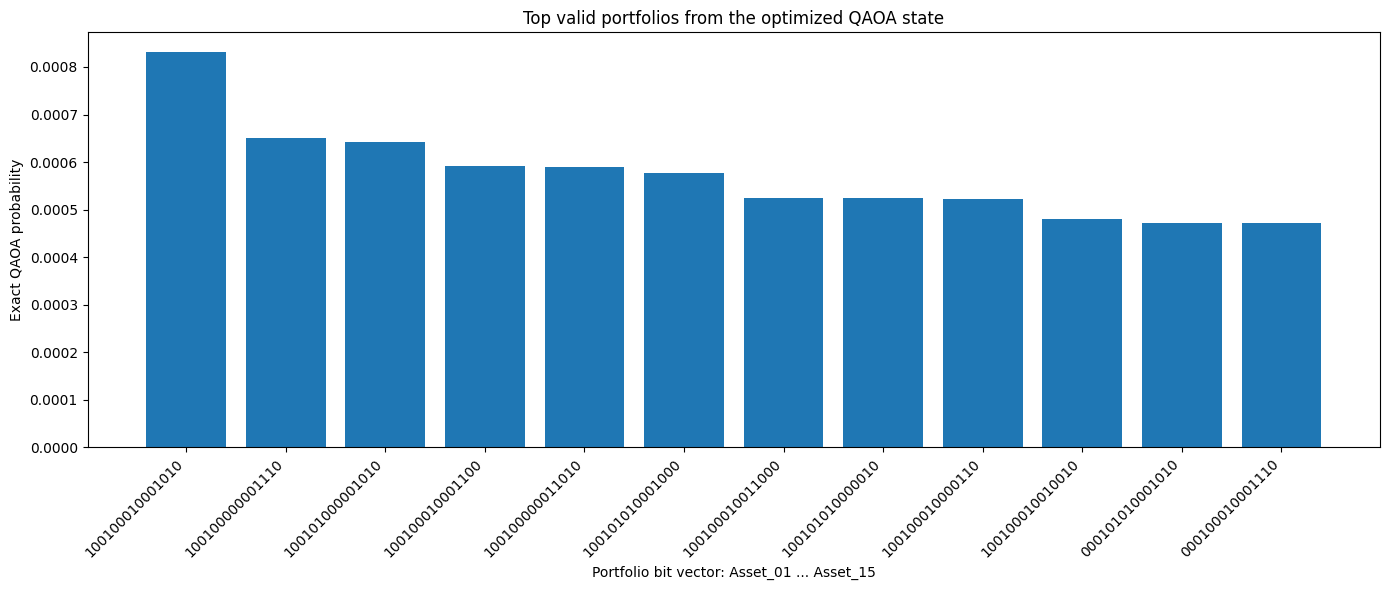

A 1 means that the corresponding asset is selected.


In [11]:
# CELL 9 — VISUALIZE THE MOST PROBABLE VALID PORTFOLIOS

valid_probs = final_probs[
    valid_mask
]

valid_ids = state_ids[
    valid_mask
]

top_order = np.argsort(
    valid_probs
)[-12:][::-1]

top_ids = valid_ids[
    top_order
]

top_probs = valid_probs[
    top_order
]

def state_label(state_id):
    """
    Return portfolio bits in Asset_01 ... Asset_15 order.
    """

    bits = (
        X[int(state_id)]
        .astype(int)
    )

    return "".join(
        str(value)
        for value in bits
    )

labels = [
    state_label(state_id)
    for state_id in top_ids
]

plt.figure(
    figsize=(14, 6)
)

plt.bar(
    np.arange(
        len(top_ids)
    ),
    top_probs
)

plt.xticks(
    np.arange(
        len(top_ids)
    ),
    labels,
    rotation=45,
    ha="right"
)

plt.ylabel(
    "Exact QAOA probability"
)

plt.xlabel(
    "Portfolio bit vector: Asset_01 ... Asset_15"
)

plt.title(
    "Top valid portfolios from the optimized QAOA state"
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR
    / "top_valid_portfolios.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(
    "A 1 means that the corresponding asset is selected."
)

In [12]:
# CELL 10 — BUILD THE GOVERNANCE AND AUDIT PACK

environment = {
    "timestamp_utc":
        UTC_NOW(),

    "python":
        sys.version,

    "platform":
        platform.platform(),

    "numpy":
        np.__version__,

    "scipy":
        importlib.metadata.version(
            "scipy"
        ),

    "anthropic":
        importlib.metadata.version(
            "anthropic"
        )
}

write_json(
    ROOT / "environment.json",
    environment
)


def sha256_file(path):
    """
    Calculate the SHA-256 digest of an audit artifact.
    """

    digest = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):
            digest.update(chunk)

    return digest.hexdigest()


manifest = {}

for path in sorted(
    ROOT.rglob("*")
):
    if (
        path.is_file()
        and path.name
        != "audit_pack.zip"
    ):

        manifest[
            str(
                path.relative_to(ROOT)
            )
        ] = {
            "sha256":
                sha256_file(path),

            "bytes":
                path.stat().st_size
        }

write_json(
    ROOT
    / "manifest_sha256.json",
    manifest
)

audit_zip = (
    ROOT
    / "audit_pack.zip"
)

with zipfile.ZipFile(
    audit_zip,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for path in sorted(
        ROOT.rglob("*")
    ):

        if (
            path.is_file()
            and path != audit_zip
        ):

            zf.write(
                path,
                arcname=str(
                    path.relative_to(ROOT)
                )
            )

append_jsonl(
    LOG_DIR / "run_log.jsonl",
    {
        "event":
            "audit_pack_created",

        "timestamp_utc":
            UTC_NOW(),

        "audit_zip":
            str(audit_zip),

        "audit_zip_sha256":
            sha256_file(audit_zip)
    }
)

print(
    "Audit pack:",
    audit_zip
)

print(
    "SHA-256:",
    sha256_file(audit_zip)
)

print(
    "Files included:",
    len(manifest)
)

Audit pack: /content/portfolio_qaoa_audit/audit_pack.zip
SHA-256: cd2c905f63c913f52d12c2bbc15e52b83629132530b6370d91f27daf630cdf1a
Files included: 10


In [13]:
# CELL 11 — CLAUDE EXPLANATION OF THE NOTEBOOK STRUCTURE AND RESULTS

from anthropic import Anthropic

api_key = userdata.get(
    "ANTHROPIC_API_KEY"
)

if not api_key:

    raise RuntimeError(
        "ANTHROPIC_API_KEY was not found. "
        "Add it in Colab using: "
        "left sidebar → Secrets."
    )

client = Anthropic(
    api_key=api_key
)

explanation_payload = {
    "configuration":
        CONFIG,

    "optimizer_summary":
        optimizer_summary,

    "portfolio_results":
        RESULTS,

    "governance_controls": [
        "fixed random seed",
        "explicit objective coefficients",
        "complete optimizer trace in JSONL",
        "exact classical benchmark over all valid 5-of-15 portfolios",
        "saved source data and encoded state costs",
        "environment snapshot",
        "SHA-256 manifest",
        "LLM prompt and response logging"
    ]
}

prompt = f"""
You are an independent model-risk reviewer explaining a quantum
portfolio optimization notebook to a financially sophisticated audience.

Explain:

1. The 11-cell architecture.
2. How 15 binary asset-selection decisions become 15 qubits.
3. How return, covariance risk, and the exactly-five-assets constraint
   form the cost Hamiltonian.
4. How QAOA applies cost phases and a mixer.
5. The optimized gamma and beta.
6. The selected QAOA portfolio and its financial metrics.
7. The comparison with the exact classical benchmark and the
   optimality gap.
8. The governance controls, auditability, limitations, and what must
   be validated before any production use.

Do not claim quantum advantage.

Clearly distinguish a pedagogical statevector simulation from execution
on quantum hardware.

Use precise but accessible language.

DATA:

{json.dumps(explanation_payload, indent=2)}
""".strip()

response = client.messages.create(
    model=CONFIG["model_name"],
    max_tokens=2200,
    temperature=0,
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

explanation = "".join(
    block.text
    for block in response.content
    if getattr(
        block,
        "type",
        None
    ) == "text"
)

llm_audit = {
    "timestamp_utc":
        UTC_NOW(),

    "model":
        CONFIG["model_name"],

    "temperature":
        0,

    "max_tokens":
        2200,

    "prompt_sha256":
        hashlib.sha256(
            prompt.encode("utf-8")
        ).hexdigest(),

    "prompt":
        prompt,

    "response":
        explanation,

    "usage": {
        "input_tokens":
            getattr(
                response.usage,
                "input_tokens",
                None
            ),

        "output_tokens":
            getattr(
                response.usage,
                "output_tokens",
                None
            )
    }
}

write_json(
    LOG_DIR
    / "llm_explanation_audit.json",
    llm_audit
)

(
    RESULT_DIR
    / "llm_explanation.txt"
).write_text(
    explanation,
    encoding="utf-8"
)

# Rebuild the manifest and ZIP so the LLM evidence
# is included in the final audit package.

manifest = {}

for path in sorted(
    ROOT.rglob("*")
):
    if (
        path.is_file()
        and path.name
        not in {
            "audit_pack.zip",
            "manifest_sha256.json"
        }
    ):

        manifest[
            str(
                path.relative_to(ROOT)
            )
        ] = {
            "sha256":
                sha256_file(path),

            "bytes":
                path.stat().st_size
        }

write_json(
    ROOT
    / "manifest_sha256.json",
    manifest
)

with zipfile.ZipFile(
    audit_zip,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for path in sorted(
        ROOT.rglob("*")
    ):

        if (
            path.is_file()
            and path != audit_zip
        ):

            zf.write(
                path,
                arcname=str(
                    path.relative_to(ROOT)
                )
            )

print(explanation)

print(
    "\nUpdated audit pack:",
    audit_zip
)

print(
    "Updated SHA-256:",
    sha256_file(audit_zip)
)

# Independent Model-Risk Review: 15-Asset QAOA Portfolio Optimization

## Executive Summary

This notebook demonstrates a **pedagogical quantum-classical hybrid workflow** for constrained portfolio selection using the Quantum Approximate Optimization Algorithm (QAOA). The system selects 5 assets from 15 candidates by minimizing a cost function that balances expected return, volatility, and cardinality constraints. The QAOA solution achieves a **4.78% optimality gap** relative to an exhaustive classical benchmark—a meaningful but non-negligible shortfall. This review clarifies the architecture, validates the methodology, and identifies critical governance and validation requirements before any production consideration.

---

## 1. The 11-Cell Architecture

The notebook is organized as a modular pipeline:

| Cell | Function | Output |
|------|----------|--------|
| 1 | Configuration & imports | Hyperparameters, random seed, optimizer settings |
| 2 | Asset data ingestion | 15 assets with

##3.CONCLUSIONS



This notebook demonstrates how a classical portfolio-selection problem can be mapped into the mathematical framework of quantum optimization. The process begins with a familiar financial objective: select a subset of assets that provides an attractive balance between expected return and covariance-based risk. The decision is constrained so that exactly five assets must be chosen from a universe of fifteen. Although real portfolio management often involves continuous weights, transaction costs, liquidity restrictions, turnover limits, and multiple investment horizons, the binary selection problem offers a clear and rigorous starting point for studying quantum portfolio models.

The first major conceptual step is the representation of each asset-selection decision as a binary variable. Fifteen assets therefore require fifteen binary decisions, which can be associated with fifteen qubits. Each computational-basis state represents one possible portfolio. A bit value of one indicates inclusion, while zero indicates exclusion. This creates a one-to-one correspondence between classical portfolio combinations and quantum basis states. The complete search space contains \(32{,}768\) portfolios, although only those containing exactly five selected assets satisfy the investment rule.

The portfolio objective is encoded as a QUBO containing return, risk, and constraint components. Expected return is rewarded by subtracting the return score from the cost. Covariance risk is represented by a quadratic expression involving pairs of asset-selection variables. The requirement to select exactly five assets is enforced through a squared penalty. This penalty is zero for valid portfolios and becomes increasingly costly as a portfolio moves away from the required cardinality.

Once the QUBO has been defined, its values can be interpreted as the eigenvalues of a diagonal cost Hamiltonian. This is the essential bridge between classical optimization and quantum mechanics. Each portfolio basis state remains the same state when acted upon by the Hamiltonian, but it is associated with its own objective-function value. The Hamiltonian therefore represents the entire classical optimization landscape in operator form.

QAOA uses this Hamiltonian to create a cost-dependent phase transformation. The operation \(e^{-i\gamma H_C}\) assigns a different phase to every portfolio according to its cost. This operation alone does not alter measurement probabilities. The mixer transformation is therefore applied afterward. The mixer allows amplitudes to move between neighboring portfolio states, creating interference between components that acquired different phases. Through the combined action of the cost and mixer transformations, the probability distribution can be shifted toward better portfolio candidates.

The gamma and beta parameters determine how strongly these two transformations act. They are optimized using a classical numerical procedure. The notebook first performs a coarse deterministic search and then refines the best candidate using L-BFGS-B. This structure provides a clear example of a hybrid quantum-classical algorithm. The quantum component produces a parameterized probability distribution and expected cost, while the classical component searches for improved parameter values.

After optimization, the notebook samples the final probability distribution. Sampling is a critical step because a quantum algorithm does not normally return the complete statevector. Instead, repeated measurements produce classical bit strings. In the simulation, these measurements are reproduced using NumPy and the exact state probabilities. The notebook retains valid five-asset portfolios and reports the lowest-cost valid portfolio that was actually observed.

The financial interpretation is then restored. Selected assets receive equal weights, and the notebook calculates expected return, volatility, and a simplified Sharpe ratio. These metrics allow the quantum-selected portfolio to be discussed in standard investment language. Importantly, the notebook also computes the exact classical optimum by evaluating every valid five-asset combination. Because there are only \(\binom{15}{5}=3{,}003\) valid portfolios, exhaustive enumeration is straightforward.

This exact benchmark is essential. It prevents the QAOA output from being evaluated solely on the basis of appearance or intuition. The optimality gap provides an objective measure of performance. If the gap is zero, the sampled QAOA solution matches the exact optimum. If the gap is positive, the model has found a suboptimal portfolio, and the size of the gap quantifies the difference. This comparison reinforces an important principle: quantum optimization models should be tested against the strongest practical classical benchmark available.

The experiment does not demonstrate quantum advantage. The statevector is simulated on a classical computer, the problem is small, and exhaustive search is computationally inexpensive. The purpose is instructional and architectural. It demonstrates the complete chain from financial assumptions to binary variables, from a QUBO to a Hamiltonian, from a Hamiltonian to unitary quantum evolution, and from a quantum probability distribution back to a classical portfolio.

The notebook also illustrates the importance of model governance. Quantum models are not exempt from the requirements applied to conventional financial models. Their assumptions must be explicit, their inputs reproducible, their parameters recorded, and their outputs benchmarked. The notebook therefore captures the configuration, random seed, financial data, state-space encoding, optimizer trace, exact solution, selected portfolio, environment versions, and cryptographic hashes.

The resulting audit package enables an independent reviewer to reconstruct what happened during the model run. JSON and JSONL files preserve structured evidence. The optimizer trace shows how gamma and beta were evaluated. The encoded problem can be inspected separately. The sampled-state file records the observed outcomes. SHA-256 hashes make later changes detectable. This evidence does not replace economic validation, but it creates the foundation required for serious model review.

The LLM component is intentionally separated from the numerical model. Claude Haiku explains the completed analysis but does not choose assets, calculate risks, determine parameters, or alter the results. The model receives structured outputs only after the optimization has finished. Its prompt and response are logged, its temperature is controlled, and its exact model identifier is recorded. This separation is a key governance principle: generative AI may improve communication without becoming an unobserved source of numerical model decisions.

Several limitations remain. The financial inputs are synthetic. Expected returns are assumed known, even though they are among the most uncertain quantities in portfolio management. The covariance matrix is static and generated from a simplified factor structure. The model does not include transaction costs, turnover, liquidity, market impact, minimum position sizes, sector constraints, taxes, or parameter uncertainty. The final allocation is equal weighted rather than continuously optimized. In addition, the QAOA depth is only one, which limits the expressive power of the variational circuit.

A production-grade extension would require historical or forecast data under formal data-quality controls, robust estimation of expected returns and covariance, stress testing, sensitivity analysis, transaction-cost modeling, and out-of-sample evaluation. The cardinality penalty would require calibration, and alternative constraint-preserving mixers should be considered. Deeper QAOA circuits could be tested, although greater depth increases computational and hardware requirements. Results should also be compared against mixed-integer quadratic programming, heuristic search, and established portfolio-optimization methods.

Execution on actual quantum hardware would introduce additional complications. Hardware noise, finite connectivity, gate errors, measurement errors, circuit transpilation, and limited coherence could materially change the results. A statevector simulation represents ideal quantum evolution and should not be interpreted as evidence that the same probability distribution can be produced reliably on present-day hardware.

The broader lesson is that quantum portfolio optimization is best understood as a structured translation exercise. The financial problem must first be defined clearly. The decision variables must then be encoded. The objective must be converted into a Hamiltonian. Quantum transformations must be designed to process that Hamiltonian. Finally, measurement results must be decoded and evaluated using ordinary financial criteria.

This notebook provides a complete, transparent example of that process. It combines portfolio theory, binary optimization, quantum mechanics, classical parameter search, exact benchmarking, model governance, and controlled LLM reporting. Its main contribution is not the claim that quantum computing already outperforms classical portfolio methods. Its contribution is to show, step by step, how a financial optimization problem can be transformed into a quantum computational architecture while preserving explainability, reproducibility, and auditability.